In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
np.random.seed(42)

x = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(x).ravel()
y = y + 0.1 * np.random.randn(100)

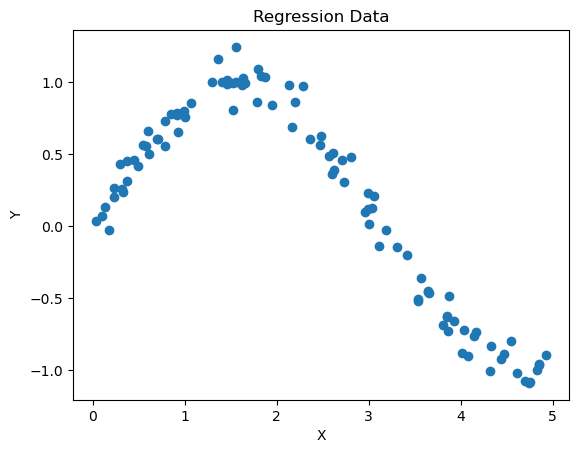

In [4]:
plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regression Data")
plt.show()

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42
)

In [6]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

In [7]:
x_train_scaled = scaler_x.fit_transform(x_train)
x_test_scaled = scaler_x.transform(x_test)

In [8]:
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

In [9]:
svr_model = SVR(kernel="rbf")

In [12]:
svr_model.fit(x_train_scaled, y_train_scaled)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [13]:
y_pred_scaled = svr_model.predict(x_test_scaled)

In [14]:
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

In [15]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.0714725225738821
MSE: 0.00802204713665235
RMSE: 0.08956588154343344
R2 Score: 0.9833545785281327


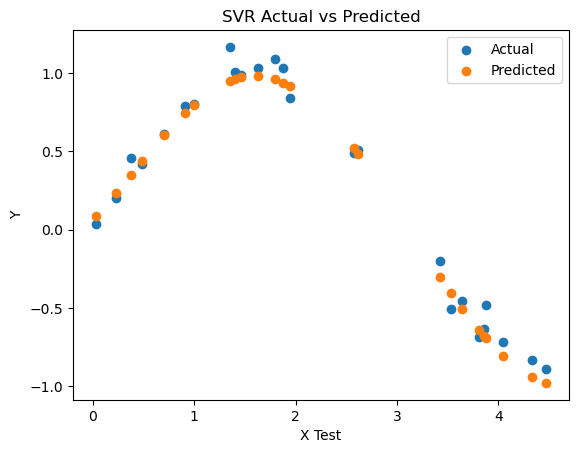

In [16]:
plt.scatter(x_test, y_test, label="Actual")
plt.scatter(x_test, y_pred, label="Predicted")
plt.xlabel("X Test")
plt.ylabel("Y")
plt.title("SVR Actual vs Predicted")
plt.legend()
plt.show()

In [17]:
x_grid = np.arange(min(x), max(x), 0.01).reshape(-1, 1)

C:\Users\Haemimont\AppData\Local\Temp\ipykernel_40484\3708594843.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_grid = np.arange(min(x), max(x), 0.01).reshape(-1, 1)


In [18]:
x_grid_scaled = scaler_x.transform(x_grid)

In [19]:
y_grid_scaled = svr_model.predict(x_grid_scaled)

In [20]:
y_grid = scaler_y.inverse_transform(y_grid_scaled.reshape(-1, 1)).ravel()

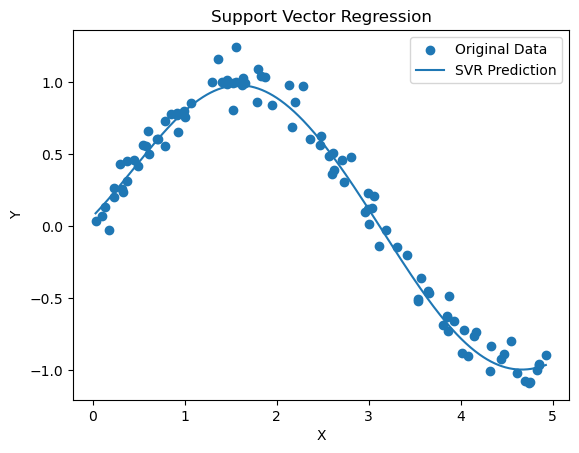

In [21]:
plt.scatter(x, y, label="Original Data")
plt.plot(x_grid, y_grid, label="SVR Prediction")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Support Vector Regression")
plt.legend()
plt.show()

In [22]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [1, 0.1, 0.01, 0.001],
    "epsilon": [0.01, 0.1, 0.2],
    "kernel": ["rbf"]
}

In [23]:
grid = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    verbose=3
)

In [24]:
grid.fit(x_train_scaled, y_train_scaled)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV 1/5] END C=0.1, epsilon=0.01, gamma=1, kernel=rbf;, score=0.958 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.01, gamma=1, kernel=rbf;, score=0.914 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.01, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.01, gamma=1, kernel=rbf;, score=0.930 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.01, gamma=1, kernel=rbf;, score=0.959 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=rbf;, score=0.575 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=rbf;, score=0.453 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=rbf;, score=0.538 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=rbf;, score=0.469 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=rbf;, score=0.370 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.01, gamma=0.01, kernel=rbf;,

,estimator,SVR()
,param_grid,"{'C': [0.1, 1, ...], 'epsilon': [0.01, 0.1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [25]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'epsilon': 0.1, 'gamma': 1, 'kernel': 'rbf'}
0.9742854543327889


In [26]:
best_pred_scaled = grid.predict(x_test_scaled)

best_pred = scaler_y.inverse_transform(
    best_pred_scaled.reshape(-1, 1)
).ravel()

In [27]:
print("MAE:", mean_absolute_error(y_test, best_pred))
print("MSE:", mean_squared_error(y_test, best_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R2 Score:", r2_score(y_test, best_pred))

MAE: 0.07147252257388208
MSE: 0.008022047136652354
RMSE: 0.08956588154343345
R2 Score: 0.9833545785281327
